# Drifter L2 data inertial oscillations filter 
- for a given trajectory plot the drifter velocity vectors and the interpolated field vectors
- apply a wavelet filter to remove inertial oscillations from drifters data
- comparison : FIELD with/without SWOT  &
               DRIFTERS with/without filter

In [1]:
import os
from glob import glob

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.geodesic import Geodesic

import numpy as np
import xarray as xr
import pandas as pd

import jax
import jax.numpy as jnp
import jaxparrow as jpw

%matplotlib inline
from matplotlib import pyplot as plt

path_save_plot = './save_plots/save_plots_2024-06-13_DrifterL2_inertial_oscillations_filter/'

In [2]:
drifters_directory = '/home/bouxdecl/Documents/data/all_drifters_sharing'

## Data selection

In [3]:
data_dir = '/home/bouxdecl/Documents/data/all_drifters_sharing'
L2_dir = drifters_directory + '/L2'
os.listdir(L2_dir)[:5]

['L2_svp_scripps_10min_lowess_10min_v0.nc',
 'L2_carthe_uwa_5min_variational_10min_v0.nc',
 'L2_svp_ogs_1h_variational_10min_v0.nc',
 'L2_svp_bcg_10min_variational_10min_v0.nc',
 'L2_svp_scripps_10min_lowess_30min_v0.nc']

filename convention : L1_type_source_aaaammjj_hhmmss_sampling.format

In [4]:
def file_selection_mediterranean(files):
    # only mediterranean (not containing 'uwa') 

    selected_files = []
    for file in files:
         if not file.count("uwa"):
            selected_files.append(file)
    return selected_files

def file_selection_by_method(files, method: str):
    # files from one interpolation method: 'variationnal' or 'lowess'

    selected_files = []
    for file in files:
         if file.count(method):
            selected_files.append(file)
    return selected_files

def file_selection_by_sampling(files, sampling: str):
    # files from one smooth L2 sampling: '10min', '30min', '1h' at the end of the file_name

    selected_files = []
    for file in files:
         if file[-11:].count(sampling):
            selected_files.append(file)
    return selected_files


In [5]:
mediterranea_files = file_selection_mediterranean(os.listdir(L2_dir))

file_lowess_10min = file_selection_by_method(mediterranea_files, "lowess")
file_lowess_10min = file_selection_by_sampling(file_lowess_10min, "10min")

file_lowess_30min = file_selection_by_method(mediterranea_files, "lowess")
file_lowess_30min = file_selection_by_sampling(file_lowess_30min, "30min")

file_lowess_1h = file_selection_by_method(mediterranea_files, "lowess")
file_lowess_1h = file_selection_by_sampling(file_lowess_1h, "1h")

## One trajectory filtering

In [261]:
# load one file
file = 'L2_svp_ogs_10min_lowess_10min_v0.nc'

ds = xr.open_dataset(os.path.join(L2_dir, file))
ds_traj = ds.isel(id=0)#.isel(time=slice(1000, 2000))

In [262]:
def get_velocities_array(ds_traj, vector_spacing):
    vector_spacing = 30
    time_vec = ds_traj.time.values[::vector_spacing]
    lat_vec  = ds_traj.lat.values[::vector_spacing]
    lon_vec  = ds_traj.lon.values[::vector_spacing]
    u_vec    = ds_traj.u.values[::vector_spacing]
    v_vec    = ds_traj.v.values[::vector_spacing]
    return time_vec, lat_vec, lon_vec, u_vec, v_vec

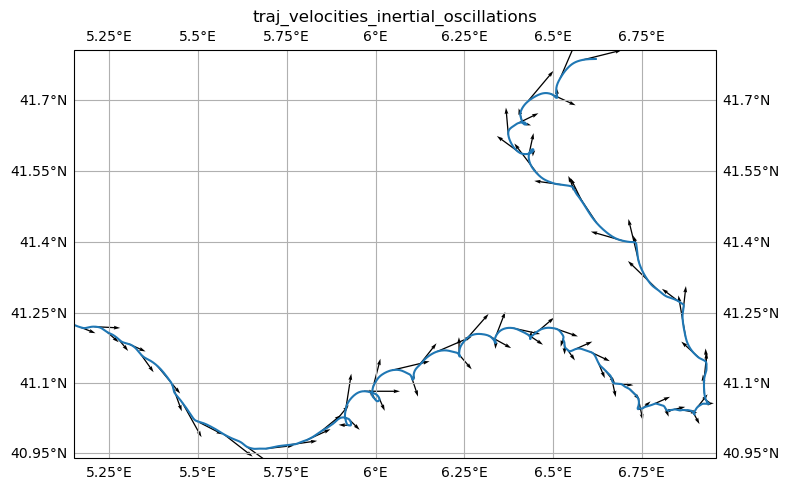

In [263]:
ds_traj = ds_traj
time_vec, lat_vec, lon_vec, u_vec, v_vec = get_velocities_array(ds_traj, vector_spacing = 30)
scale = 3e-5
width = 2e-3

# Plot the trajectory with the velocity vectors

fig = plt.figure(tight_layout=True, figsize=(8, 8))
crs = ccrs.PlateCarree()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
gl = ax.gridlines(draw_labels=True,)
ax.add_feature(cfeature.LAND,)

# trajectory
ax.plot(ds_traj.lon, ds_traj.lat,transform=crs)
# vectors
ax.quiver(lon_vec, lat_vec, u_vec, v_vec, angles='xy', scale_units='xy', scale=scale, width=width, transform=ccrs.PlateCarree())

plot_marge = 0.02
ax.set_extent([np.nanmin(lon_vec) - plot_marge, np.nanmax(lon_vec) + plot_marge, np.nanmin(lat_vec) - plot_marge, np.nanmax(lat_vec) + plot_marge], crs=ccrs.PlateCarree())

### SAVE
ax.set_title("traj_velocities_inertial_oscillations")
save_name = 'traj_velocities_inertial_oscillations.png'
plt.savefig(os.path.join(path_save_plot,save_name), bbox_inches='tight', dpi = 300)

In [264]:
time_span = (time.values[-1] - time.values[0]) / (3600*1e9)
time_span #hours

numpy.timedelta64(166,'ns')

#### filter

In [265]:
u = ds_traj.u
v = ds_traj.v
lon = ds_traj.lon
lat = ds_traj.lat
time = ds_traj.time
n_points = len(time)

U = u+1j*v

n_points

3015

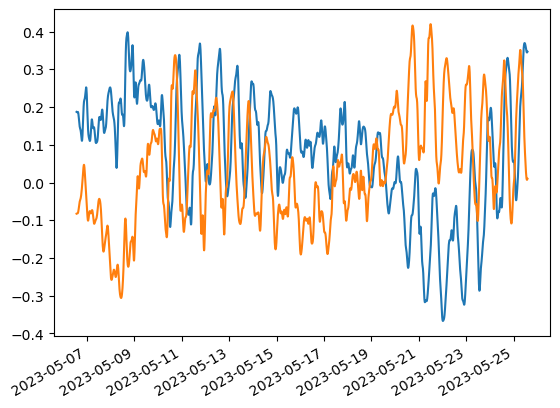

In [266]:
plt.plot(time, u)
plt.plot(time, v)
plt.gcf().autofmt_xdate()

In [267]:
12.9/np.sin(41/180 * np.pi) # theoretical inertial period

19.662864818505003

In [268]:
1/(2*(2*np.pi/86400))

6875.493541569879

on observe bien ce phénomène car la période observée est de 3/4 de jours soit ~18h 

On essaye à présent de filter cette composante

In [325]:
# define taul for each drifter point = period of the inertial oscillations
fc = 2*(2*np.pi/86400)*np.sin(lat*np.pi/180)  # s-1
taul = 1* 1/fc

In [326]:
# wavelet function at each point
fc = jnp.array(fc)
taul = jnp.array(taul)
tt = jnp.arange(-2*86400,2*86400+3600,10*60) # time array : each hour for 6 days
gl = (jnp.exp(-1j*jnp.outer(fc,tt))*jnp.exp(-jnp.outer(2*taul**-2,tt**2))).reshape(n_points,len(tt))

# normalization
row_sums = np.sum(np.abs(gl), axis=1)[:, np.newaxis] + 1e-10
gl = gl / row_sums

In [327]:
# time convolution at each point
Unil = U*0.+np.nan
for point in range(n_points):
    Unil = np.convolve(U[:],gl[point, :],'same')

In [328]:
u_oscil, v_oscil = Unil.real, Unil.imag

u_process = u - u_oscil
v_process = v - v_oscil

In [329]:
vector_spacing = 30
u_process_vec = u_process[::vector_spacing]
v_process_vec = v_process[::vector_spacing]

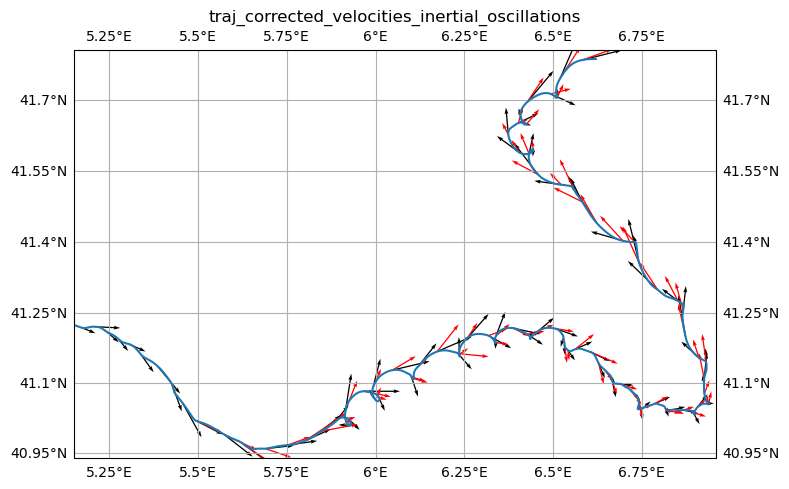

In [330]:
ds_traj = ds_traj
time_vec, lat_vec, lon_vec, u_vec, v_vec = get_velocities_array(ds_traj, vector_spacing = 30)
scale = 3e-5
width = 2e-3

# Plot the trajectory with the velocity vectors

fig = plt.figure(tight_layout=True, figsize=(8, 8))
crs = ccrs.PlateCarree()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
gl = ax.gridlines(draw_labels=True,)
ax.add_feature(cfeature.LAND,)

# trajectory
ax.plot(ds_traj.lon, ds_traj.lat,transform=crs)
# vectors
ax.quiver(lon_vec, lat_vec, u_vec, v_vec, color='black', angles='xy', scale_units='xy', scale=scale, width=width, transform=ccrs.PlateCarree())
ax.quiver(lon_vec, lat_vec, u_process_vec, v_process_vec, color='r', angles='xy', scale_units='xy', scale=scale, width=width, transform=ccrs.PlateCarree())

plot_marge = 0.02
ax.set_extent([np.nanmin(lon_vec) - plot_marge, np.nanmax(lon_vec) + plot_marge, np.nanmin(lat_vec) - plot_marge, np.nanmax(lat_vec) + plot_marge], crs=ccrs.PlateCarree())

### SAVE
ax.set_title("traj_corrected_velocities_inertial_oscillations")
save_name = 'traj_corrected_velocities_inertial_oscillations.png'
plt.savefig(os.path.join(path_save_plot,save_name), bbox_inches='tight', dpi = 300)

In [331]:
#cd.kinematics.inertial_oscillation_from_position(lon.values, lat.values, wavelet_duration=float(taul[0, 0]), time_step=10*60) # 10min sampling